# Iris Flower Classification 

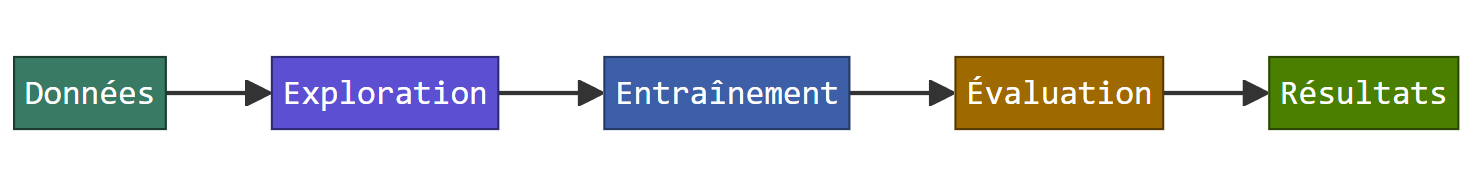

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

###  Load & Explore the Data

In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("=== Data Preview ===")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nClass distribution:\n{df['species_name'].value_counts()}")
print(f"\nDescriptive statistics:\n{df.describe()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

=== Data Preview ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3    

### Visualizations

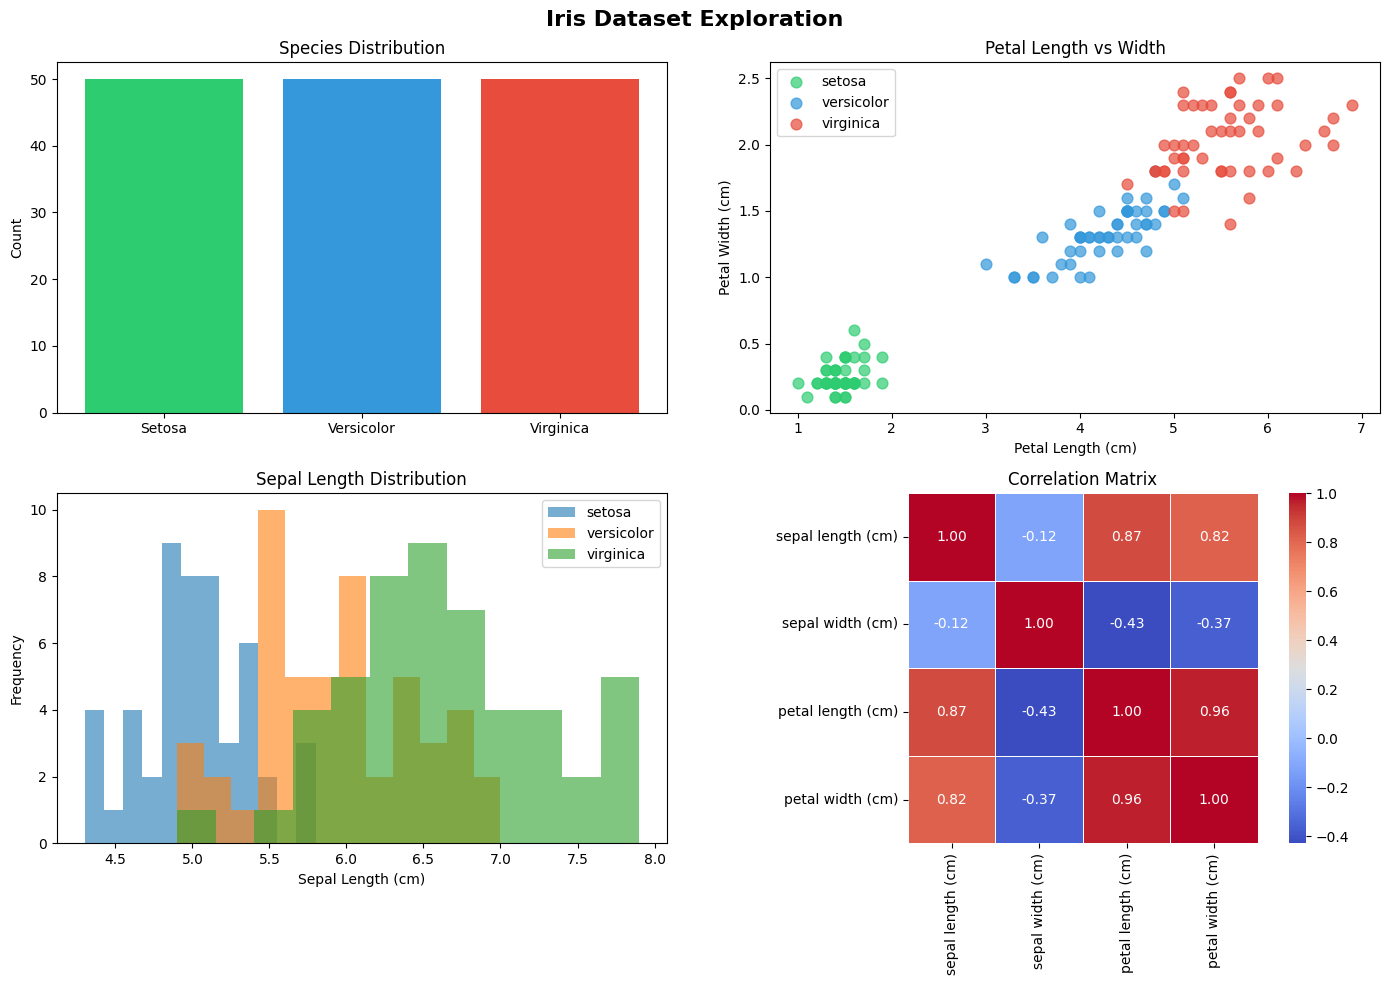

Charts saved.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Dataset Exploration', fontsize=16, fontweight='bold')

# 1. Species distribution
axes[0, 0].bar(['Setosa', 'Versicolor', 'Virginica'],
               df['species_name'].value_counts().values,
               color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0, 0].set_title('Species Distribution')
axes[0, 0].set_ylabel('Count')

# 2. Petal length vs width
colors = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c'}
for species in [0, 1, 2]:
    mask = df['species'] == species
    axes[0, 1].scatter(df.loc[mask, 'petal length (cm)'],
                       df.loc[mask, 'petal width (cm)'],
                       c=colors[species], label=iris.target_names[species], alpha=0.7, s=60)
axes[0, 1].set_xlabel('Petal Length (cm)')
axes[0, 1].set_ylabel('Petal Width (cm)')
axes[0, 1].set_title('Petal Length vs Width')
axes[0, 1].legend()

# 3. Sepal length histogram
for species in [0, 1, 2]:
    mask = df['species'] == species
    axes[1, 0].hist(df.loc[mask, 'sepal length (cm)'], alpha=0.6,
                    label=iris.target_names[species], bins=12)
axes[1, 0].set_xlabel('Sepal Length (cm)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Sepal Length Distribution')
axes[1, 0].legend()

# 4. Correlation heatmap
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1],
            square=True, linewidths=0.5)
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('iris_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved.")

### Prepare the Data

In [4]:
# Features / target split
X = df[iris.feature_names]
y = df['species']

# Train/test split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 120
Testing samples  : 30


### Train 3 Models

In [5]:
# Define models
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'predictions': y_pred, 'accuracy': acc}
    print(f"{name:25s} → Accuracy: {acc*100:.2f}%")

K-Nearest Neighbors       → Accuracy: 93.33%
Decision Tree             → Accuracy: 93.33%
Random Forest             → Accuracy: 90.00%


### Detailed Evaluation

=== Best model: K-Nearest Neighbors (93.33%) ===

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



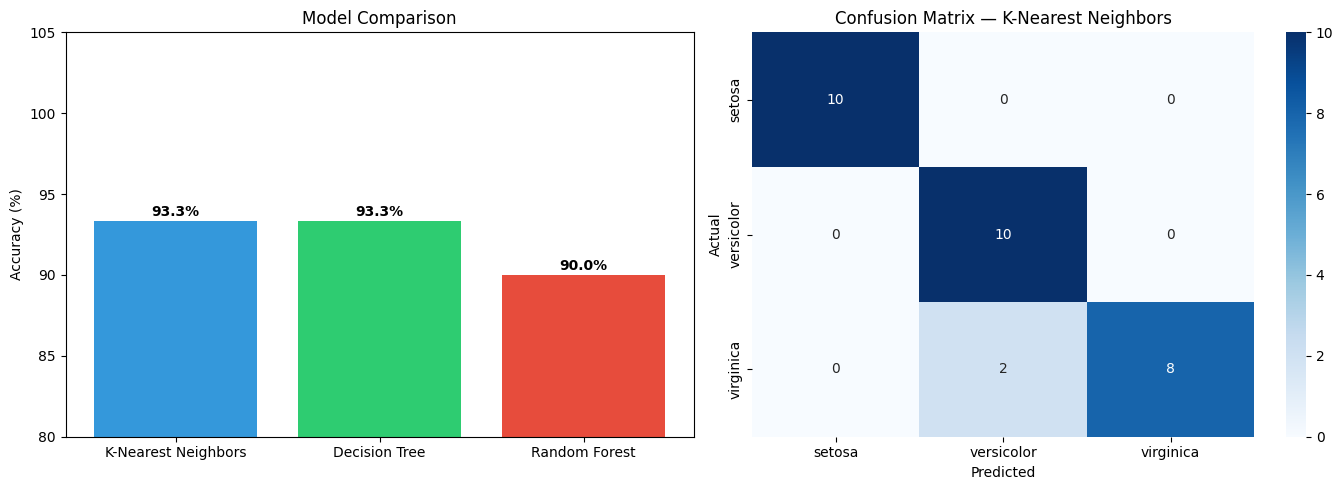

In [6]:
# Select the best model
best_name = max(results, key=lambda k: results[k]['accuracy'])
best = results[best_name]
print(f"=== Best model: {best_name} ({best['accuracy']*100:.2f}%) ===\n")

# Classification report
print(classification_report(y_test, best['predictions'], target_names=iris.target_names))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
names = list(results.keys())
accs  = [results[n]['accuracy'] * 100 for n in names]
bars  = axes[0].bar(names, accs, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_ylim(80, 105)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Comparison')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, best['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=iris.target_names, yticklabels=iris.target_names)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix — {best_name}')

plt.tight_layout()
plt.savefig('iris_results.png', dpi=150, bbox_inches='tight')
plt.show()

### Predict a New Flower

In [7]:
# New flower to classify (feel free to change the values)
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])  # [sepal_l, sepal_w, petal_l, petal_w]
new_flower_scaled = scaler.transform(new_flower)

print("=== Prediction Test ===")
for name, res in results.items():
    pred = res['model'].predict(new_flower_scaled)[0]
    print(f"{name:25s} → {iris.target_names[pred]}")

=== Prediction Test ===
K-Nearest Neighbors       → setosa
Decision Tree             → setosa
Random Forest             → setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
